# PyTorch Laboratory

![PyTorch](https://upload.wikimedia.org/wikipedia/commons/thumb/c/c6/PyTorch_logo_black.svg/960px-PyTorch_logo_black.svg.png)

Laboratory Lecture for the **Generative and Deep Learning** course — Master's Degree in Computer Science (2025–2026)

Riccardo Massidda — riccardo.massidda@di.unipi.it

In [1]:
import torch

print(f"Using torch v{torch.__version__}")

Using torch v2.11.0+cpu


---
## Tensor Initialization

Tensors are the main data structure: multidimensional arrays with support for GPU acceleration, automatic differentiation, and NumPy-like indexing/broadcasting.

Key attributes:
- `dtype`: element type (`float32`, `float64`, `bfloat16`, `int64`, `uint8`, …)
- `device`: memory location (`cpu`, `cuda`, `mps`)
- `layout`: dense (`strided`) or sparse (`sparse_coo`)

In [2]:
# Initialize a dense tensor of zeros
dims = (4, 5, 3)
t = torch.zeros(*dims)
print(f"Shape:  {t.shape}")
print(f"Type:   {t.dtype}")
print(f"Layout: {t.layout}")
print(t)

Shape:  torch.Size([4, 5, 3])
Type:   torch.float32
Layout: torch.strided
tensor([[[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]],

        [[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]],

        [[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]],

        [[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]]])


In [3]:
# Initialize a sparse tensor of zeros
t_sparse = torch.zeros(*dims, layout=torch.sparse_coo)
print(f"Shape:  {t_sparse.shape}")
print(f"Type:   {t_sparse.dtype}")
print(f"Layout: {t_sparse.layout}")
print(t_sparse)

Shape:  torch.Size([4, 5, 3])
Type:   torch.float32
Layout: torch.sparse_coo
tensor(indices=tensor([], size=(3, 0)),
       values=tensor([], size=(0,)),
       size=(4, 5, 3), nnz=0, layout=torch.sparse_coo)


In [ ]:
# Define the indices for the non-zero elements
indices = torch.tensor([[0, 1], [2, 2], [3, 5]])

# Define the corresponding values
values = torch.tensor([2.5, -1.5])

new_t_sparse = torch.sparse_coo_tensor(indices, values, dims)

print(f"Shape:  {new_t_sparse.shape}")
print(f"Type:   {new_t_sparse.dtype}")
print(f"Layout: {new_t_sparse.layout}")
print(new_t_sparse)

# You can convert it to a dense tensor to see the values clearly
print("\nDense representation:\n", new_t_sparse.to_dense())

Shape:  torch.Size([4, 5, 3])
Type:   torch.float32
Layout: torch.sparse_coo
tensor(indices=tensor([[0, 1],
                       [2, 2],
                       [3, 5]]),
       values=tensor([ 2.5000, -1.5000]),
       size=(4, 5, 3), nnz=2, layout=torch.sparse_coo)

Dense representation:
 tensor([[[ 0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000],
         [ 2.5000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000]],

        [[ 0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000, -1.5000],
         [ 0.0000,  0.0000,  0.0000]],

        [[ 0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000]],

        [[ 0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000],
         [ 0.0000,  0.0000,  0.0000],
         [ 0.0000

/tmp/ipykernel_18869/2201949437.py:7: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:760.)
  new_t_sparse = torch.sparse_coo_tensor(indices, values, dims)


In [5]:
# Random tensors
t1 = torch.randn(*dims)  # Standard normal
t2 = torch.rand(*dims)  # Uniform [0, 1)
t3 = torch.randint(-10, 10, dims)  # Uniform integers

print(f"t1 dtype: {t1.dtype}")  # float32
print(f"t2 dtype: {t2.dtype}")  # float32
print(f"t3 dtype: {t3.dtype}")  # int64

print("t1:\n", t1)
print("t2:\n", t2)
print("t3:\n", t3)

t1 dtype: torch.float32
t2 dtype: torch.float32
t3 dtype: torch.int64
t1:
 tensor([[[ 1.5950,  2.0090,  0.7692],
         [ 0.6459, -0.2882,  0.9986],
         [ 0.6055,  0.6672,  0.2341],
         [ 0.0380, -0.3087,  1.2433],
         [-0.5007, -0.6206, -0.3397]],

        [[ 0.5869, -0.1704, -0.2124],
         [ 2.1074, -0.5786,  0.2066],
         [-0.1226,  1.2829, -1.7251],
         [ 0.5752,  0.0041, -0.3854],
         [-1.8582, -1.7429, -0.2601]],

        [[ 0.1829, -1.0441,  0.8244],
         [-0.8743,  0.8826, -0.3227],
         [-0.6907,  0.4960, -0.0434],
         [-2.2522, -2.0651,  1.2965],
         [-0.9609,  0.0657,  1.5799]],

        [[-0.7163,  2.1674,  0.3028],
         [ 2.2867, -0.6994,  0.0929],
         [ 0.7676,  1.0111,  1.8035],
         [-2.0950, -0.5233, -1.3364],
         [ 0.3823,  0.3959,  0.8797]]])
t2:
 tensor([[[0.0878, 0.7932, 0.9785],
         [0.7734, 0.6362, 0.5655],
         [0.8019, 0.9026, 0.4790],
         [0.8298, 0.9136, 0.5364],
         [0.

In [6]:
import numpy as np

# Other initialization methods
print(torch.ones(2, 3))
print(torch.linspace(0, 1, steps=5))

arr = np.array([1, 2, 3])
print(torch.from_numpy(arr))

tensor([[1., 1., 1.],
        [1., 1., 1.]])
tensor([0.0000, 0.2500, 0.5000, 0.7500, 1.0000])
tensor([1, 2, 3])


In [7]:
# Types are promoted automatically by operators
t4 = t1 + t2 * t3
print(f"t4 dtype: {t4.dtype}")  # float32 (int64 promoted)

t4 dtype: torch.float32


In [8]:
# Manual type casting
torch.manual_seed(42)
dims = (3, 2)
t5 = torch.randint(0, 2, dims)
print(f"Original ({t5.dtype}):\n{t5}")
print(f"Bool     ({t5.bool().dtype}):\n{t5.bool()}")
print(f"Float32  ({t5.float().dtype}):\n{t5.float()}")
print(f"Int64    ({t5.long().dtype}):\n{t5.long()}")
print(f"Float64  ({t5.double().dtype}):\n{t5.double()}")

Original (torch.int64):
tensor([[0, 1],
        [0, 0],
        [0, 1]])
Bool     (torch.bool):
tensor([[False,  True],
        [False, False],
        [False,  True]])
Float32  (torch.float32):
tensor([[0., 1.],
        [0., 0.],
        [0., 1.]])
Int64    (torch.int64):
tensor([[0, 1],
        [0, 0],
        [0, 1]])
Float64  (torch.float64):
tensor([[0., 1.],
        [0., 0.],
        [0., 1.]], dtype=torch.float64)


---
## Tensor Operations

Some operators are overloaded:
- `+`, `-` for addition and subtraction (support broadcasting)
- `*` is **elementwise** multiplication (not matrix product, supports broadcasting)
- `@` for matrix multiplication (`torch.matmul`)

In-place operations use a trailing underscore: `add_`, `sub_`, etc.

In [9]:
a = torch.tensor([[1.0, 2.0], [3.0, 4.0]])
b = torch.tensor([[10.0, 20.0], [30.0, 40.0]])

print("a + b =\n", a + b)  # elementwise addition
print("a * b =\n", a * b)  # elementwise multiplication
print("a @ b =\n", a @ b)  # matrix multiplication
print("torch.matmul(a, b) =\n", torch.matmul(a, b))  # same as @

a + b =
 tensor([[11., 22.],
        [33., 44.]])
a * b =
 tensor([[ 10.,  40.],
        [ 90., 160.]])
a @ b =
 tensor([[ 70., 100.],
        [150., 220.]])
torch.matmul(a, b) =
 tensor([[ 70., 100.],
        [150., 220.]])


In [10]:
# In-place operations modify the tensor directly
c = torch.zeros(2, 2)
print(f"Before: {c}")
c.add_(a)
print(f"After add_(a): {c}")

Before: tensor([[0., 0.],
        [0., 0.]])
After add_(a): tensor([[1., 2.],
        [3., 4.]])


---
## Broadcasting Rules

PyTorch broadcasting follows NumPy semantics.
Two tensors are "broadcastable" if:
1. Each tensor has at least one dimension.
2. Iterating from the **trailing** dimension, sizes must be equal, one of them is 1, or one of them does not exist.

In [11]:
# Same shapes: always broadcastable
x = torch.empty(5, 7, 3)
y = torch.empty(5, 7, 3)
print(f"(5,7,3) + (5,7,3) → {(x + y).shape}")

# Trailing dimensions: equal, or one is 1, or missing
x = torch.empty(5, 3, 4, 1)
y = torch.empty(3, 1, 1)
print(f"(5,3,4,1) + (3,1,1) → {(x + y).shape}")  # → (5,3,4,1)

# Trailing dimensions: equal, or one is 1, or missing
x = torch.empty(2, 5, 3, 4, 1)
y = torch.empty(3, 1, 1)
print(f"(2,5,3,4,1) + (3,1,1) → {(x + y).shape}")  # → (2,5,3,4,1)

(5,7,3) + (5,7,3) → torch.Size([5, 7, 3])
(5,3,4,1) + (3,1,1) → torch.Size([5, 3, 4, 1])
(2,5,3,4,1) + (3,1,1) → torch.Size([2, 5, 3, 4, 1])


In [12]:
# Not broadcastable: trailing dimension 2 != 3
x = torch.empty(5, 2, 4, 1)
y = torch.empty(3, 1, 1)
try:
    z = x + y
except RuntimeError as e:
    print(f"Error: {e}")

Error: The size of tensor a (2) must match the size of tensor b (3) at non-singleton dimension 1


In [13]:
# Concrete example: row vector + column vector
row = torch.tensor([1, 2, 3])  # shape (3,)
col = torch.tensor([[0], [10], [20], [30]])  # shape (4, 1)
result = row + col  # shape (4, 3)
print(f"row {row.shape} + col {col.shape} → {result.shape}")
print(result)

row torch.Size([3]) + col torch.Size([4, 1]) → torch.Size([4, 3])
tensor([[ 1,  2,  3],
        [11, 12, 13],
        [21, 22, 23],
        [31, 32, 33]])


In [14]:
# Scalar broadcasting: a scalar can be broadcast to any shape
x = torch.tensor([1, 2, 3])  # Shape (3,)
s = torch.tensor(10)  # Shape ()
result = x + s
print(f"x {x.shape} + s {s.shape} → {result.shape}")
print(f"Result:\n{result}")

x torch.Size([3]) + s torch.Size([]) → torch.Size([3])
Result:
tensor([11, 12, 13])


In [15]:
# Broadcasting with a 1-sized dimension
a = torch.arange(12).reshape(3, 4)  # Shape (3, 4)
b = torch.arange(4)  # Shape (4,)
result = a + b
print(f"a {a.shape} + b {b.shape} → {result.shape}")
print(f"Result:\n{result}")

a torch.Size([3, 4]) + b torch.Size([4]) → torch.Size([3, 4])
Result:
tensor([[ 0,  2,  4,  6],
        [ 4,  6,  8, 10],
        [ 8, 10, 12, 14]])


In [16]:
# Another example with 1-sized dimension
c = torch.arange(3).reshape(3, 1)  # Shape (3, 1)
d = torch.arange(4).reshape(1, 4)  # Shape (1, 4)
result = c + d
print(f"c {c.shape} + d {d.shape} → {result.shape}")
print(f"Result:\n{result}")

c torch.Size([3, 1]) + d torch.Size([1, 4]) → torch.Size([3, 4])
Result:
tensor([[0, 1, 2, 3],
        [1, 2, 3, 4],
        [2, 3, 4, 5]])


In [17]:
# Broadcasting with different number of dimensions
e = torch.arange(6).reshape(2, 3)  # Shape (2, 3)
f = torch.tensor([10, 20, 30])  # Shape (3,)
result = e * f
print(f"e {e.shape} * f {f.shape} → {result.shape}")
print(f"Result:\n{result}")

e torch.Size([2, 3]) * f torch.Size([3]) → torch.Size([2, 3])
Result:
tensor([[  0,  20,  60],
        [ 30,  80, 150]])


---
## Device Management (GPU / MPS / CPU)

The submodule `torch.cuda` provides the API for NVIDIA GPU management.
On Apple Silicon, the MPS (Metal Performance Shaders) backend is available.

All tensors in an operation must reside on the **same device**.

In [18]:
# Device-agnostic pattern
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using device: {device}")

Using device: cpu


In [19]:
# Move tensors to the accelerator
t1_dev = t1.to(device)
t2_dev = t2.to(device)
t3_dev = t3.to(device)

# Operations on the same device
t4_dev = t1_dev + t2_dev * t3_dev
print(f"Result device: {t4_dev.device}")

Result device: cpu


In [20]:
# Mixing devices raises a RuntimeError
if device != "cpu":
    try:
        bad = t4_dev + t4  # t4 is on CPU, t4_dev is on the accelerator
    except RuntimeError as e:
        print(f"Expected error: {e}")
else:
    print("Skipped (no accelerator — both tensors are on CPU)")

Skipped (no accelerator — both tensors are on CPU)


---
## Tensor Indexing

Basic indexing works like Python lists, extended to multiple dimensions.
Boolean arrays can filter elements satisfying a condition.
If fewer indices than dimensions are given, the missing indices are treated as full slices.

In [21]:
torch.manual_seed(42)
arr = torch.arange(24).reshape(3, 4, 2)
print(f"Shape: {arr.shape}")
arr

Shape: torch.Size([3, 4, 2])


tensor([[[ 0,  1],
         [ 2,  3],
         [ 4,  5],
         [ 6,  7]],

        [[ 8,  9],
         [10, 11],
         [12, 13],
         [14, 15]],

        [[16, 17],
         [18, 19],
         [20, 21],
         [22, 23]]])

In [22]:
# First two entries along dim 0
arr[:2]

tensor([[[ 0,  1],
         [ 2,  3],
         [ 4,  5],
         [ 6,  7]],

        [[ 8,  9],
         [10, 11],
         [12, 13],
         [14, 15]]])

In [23]:
# Last two entries along dim 0
arr[1:]

tensor([[[ 8,  9],
         [10, 11],
         [12, 13],
         [14, 15]],

        [[16, 17],
         [18, 19],
         [20, 21],
         [22, 23]]])

In [24]:
# Negative indexing
arr[-2:]

tensor([[[ 8,  9],
         [10, 11],
         [12, 13],
         [14, 15]],

        [[16, 17],
         [18, 19],
         [20, 21],
         [22, 23]]])

In [25]:
# Mixed indexing
arr[1:, 1:3]

tensor([[[10, 11],
         [12, 13]],

        [[18, 19],
         [20, 21]]])

In [26]:
arr[-2:, 1:3, :]

tensor([[[10, 11],
         [12, 13]],

        [[18, 19],
         [20, 21]]])

In [27]:
# Boolean indexing
even_entries = arr % 2 == 0
print(even_entries)
arr_copy = arr.clone()
arr_copy[even_entries] = -1
arr_copy

tensor([[[ True, False],
         [ True, False],
         [ True, False],
         [ True, False]],

        [[ True, False],
         [ True, False],
         [ True, False],
         [ True, False]],

        [[ True, False],
         [ True, False],
         [ True, False],
         [ True, False]]])


tensor([[[-1,  1],
         [-1,  3],
         [-1,  5],
         [-1,  7]],

        [[-1,  9],
         [-1, 11],
         [-1, 13],
         [-1, 15]],

        [[-1, 17],
         [-1, 19],
         [-1, 21],
         [-1, 23]]])

---
## Tensor Reshaping

In [28]:
t = torch.randn(3, 1, 5)
t

tensor([[[ 0.3367,  0.1288,  0.2345,  0.2303, -1.1229]],

        [[-0.1863,  2.2082, -0.6380,  0.4617,  0.2674]],

        [[ 0.5349,  0.8094,  1.1103, -1.6898, -0.9890]]])

In [29]:
t.squeeze().shape  # remove singleton dims → [3, 5]

torch.Size([3, 5])

In [30]:
t.unsqueeze(0).shape  # add dim at 0 → [1, 3, 1, 5]

torch.Size([1, 3, 1, 5])

In [31]:
t.unsqueeze(3).shape  # add dim at 3 → [3, 1, 5, 1]

torch.Size([3, 1, 5, 1])

In [32]:
t.transpose(1, 2).shape  # swap dims 1,2 → [3, 5, 1]

torch.Size([3, 5, 1])

In [33]:
t.permute(1, 0, 2).shape  # reorder → [1, 3, 5]

torch.Size([1, 3, 5])

### `view` vs `reshape`

- `view` requires the tensor to be **contiguous** in memory (raises error otherwise).
- `reshape` works on any tensor (may silently copy data).

⚠ Use `reshape` unless you specifically want the error as a safety check.

In [34]:
x = torch.randn(3, 4)

# OK: x is contiguous
x.view(12)
x.view(2, 6)

# transpose makes it non-contiguous
y = x.t()
print(f"y is contiguous: {y.is_contiguous()}")

try:
    y.view(12)  # RuntimeError!
except RuntimeError as e:
    print(f"view error: {e}")

print(y.reshape(12).shape)  # OK (silently copies)
print(y.contiguous().view(12).shape)  # OK (explicit copy)

y is contiguous: False
view error: view size is not compatible with input tensor's size and stride (at least one dimension spans across two contiguous subspaces). Use .reshape(...) instead.
torch.Size([12])
torch.Size([12])


---
## Tensor Reduction

Reduction operations collapse the tensor dimensionality: `sum`, `mean`, `prod`, `amin`, `amax`.

The `keepdim` parameter preserves a singleton dimension in place.

In [35]:
t = torch.randn(5, 2, 3)

In [36]:
red_t = t.sum(0)
print(f"Shape: {red_t.shape}")
red_t

Shape: torch.Size([2, 3])


tensor([[ 0.9238,  1.4217,  3.3792],
        [-0.3362,  3.0964, -0.8687]])

In [37]:
red_t = t.sum(0, keepdim=True)
print(f"Shape: {red_t.shape}")
red_t

Shape: torch.Size([1, 2, 3])


tensor([[[ 0.9238,  1.4217,  3.3792],
         [-0.3362,  3.0964, -0.8687]]])

In [38]:
red_t = t.mean(0)
print(f"Shape: {red_t.shape}")
red_t

Shape: torch.Size([2, 3])


tensor([[ 0.1848,  0.2843,  0.6758],
        [-0.0672,  0.6193, -0.1737]])

In [39]:
red_t = t.mean((0, 2), keepdim=True)
print(f"Shape: {red_t.shape}")
red_t

Shape: torch.Size([1, 2, 1])


tensor([[[0.3816],
         [0.1261]]])

---
## Your Turn! — Kaiming Initialization

The Kaiming uniform initialization scheme provides a standard baseline to train Neural Networks with rectified activation functions.

$$w \sim \mathcal{U}\left(-\sqrt{\frac{6}{\text{fan\_in}}},\ \sqrt{\frac{6}{\text{fan\_in}}}\right)$$

Write the following functions:
- `relu_kaiming_init_(weights)` — modifies the tensor **in-place**
- `relu_kaiming_init(in_size, out_size)` — returns a new `(out_size, in_size)` tensor

In [40]:
def relu_kaiming_init(in_size: int, out_size: int) -> torch.Tensor:
    bound = (6 / in_size) ** 0.5
    weights = torch.zeros((out_size, in_size))
    weights.uniform_(-bound, bound)
    return weights


def relu_kaiming_init_(weights: torch.Tensor):
    _, fan_in = weights.shape
    bound = (6 / fan_in) ** 0.5
    weights.uniform_(-bound, bound)


In [41]:
# --- Tests (do not modify) ---
torch.manual_seed(42)

# Shape check
t1 = relu_kaiming_init(5, 10)
assert t1.shape == (10, 5), f"Expected (10, 5), got {t1.shape}"

# In-place check
t2 = torch.zeros(30, 25)
t2_old = t2.clone()
relu_kaiming_init_(t2)
assert not torch.allclose(t2_old, t2), "In-place init did not modify the tensor"
assert torch.allclose(t2_old, torch.tensor(0.0))

# Stats
print(f"Mean: {t2.mean():.4f}")
print(f"Std:  {t2.std():.4f}")
print("All tests passed!")

Mean: -0.0236
Std:  0.2878
All tests passed!


---
## Autograd — Automatic Differentiation

The `torch.autograd` engine builds a **dynamic computation graph** during the forward pass. Each operation creates a `Function` node connected to its `Tensor` arguments. Calling `.backward()` traverses this graph in reverse to compute gradients.

Key tensor attributes:
- `.data` — the raw data
- `.grad` — accumulated gradient (initially `None`)
- `.grad_fn` — the `Function` that created this tensor

In [42]:
t = torch.randn(2, 4, 5)
t.data, t.grad, t.grad_fn

(tensor([[[ 0.9213,  0.5282, -0.0082, -1.4493, -0.6052],
          [-0.1792,  0.1996, -1.2462, -0.4146,  1.4559],
          [ 0.3317, -1.0001, -0.6920, -0.4720, -1.2894],
          [ 1.0763, -1.0667, -1.9893,  0.2973,  0.4345]],
 
         [[ 0.0034, -1.0240,  0.2240, -0.7555, -0.1349],
          [ 0.1488, -0.2378, -0.1014,  0.9077, -0.3669],
          [-0.0186,  0.0285, -1.4314, -0.0398, -0.5003],
          [ 0.2930,  0.1839, -0.7940,  1.3019, -1.0228]]]),
 None,
 None)

In [43]:
# A simple RNN step — autograd tracks everything
torch.manual_seed(42)
batch_size, in_shape, hh_shape = 32, 5, 10

# Input and hidden state (no grad needed)
x = torch.randn(batch_size, in_shape)
prev_h = torch.randn(batch_size, hh_shape)

# Parameters — we want their gradients
W_x = torch.randn(hh_shape, in_shape, requires_grad=True)
W_h = torch.randn(hh_shape, hh_shape, requires_grad=True)

# Forward: next_h = tanh(x @ W_x^T + prev_h @ W_h^T)
i2h = torch.mm(x, W_x.t())
h2h = torch.mm(prev_h, W_h.t())
next_h = (i2h + h2h).tanh()

print(f"next_h shape: {next_h.shape}")
print(f"next_h.grad_fn: {next_h.grad_fn}")

next_h shape: torch.Size([32, 10])
next_h.grad_fn: <TanhBackward0 object at 0x7f3076fffdf0>


In [44]:
# Backward: compute gradients
# For non-scalar output, pass a gradient tensor of matching shape
next_h.backward(torch.ones(batch_size, hh_shape))

# Only tensors with requires_grad=True accumulate gradients
print(f"x.grad:      {x.grad}")  # None
print(f"prev_h.grad: {prev_h.grad}")  # None
print(f"W_x.grad shape: {W_x.grad.shape}")
print(f"W_h.grad shape: {W_h.grad.shape}")

x.grad:      None
prev_h.grad: None
W_x.grad shape: torch.Size([10, 5])
W_h.grad shape: torch.Size([10, 10])


### `requires_grad`, `detach()`, `no_grad()`, `inference_mode()`

- `requires_grad=True`: autograd tracks this tensor. Use for model parameters.
- `requires_grad=False`: no tracking. Use for input data or constants.
- `.detach()`: returns a new tensor sharing data but **outside** the graph.
- `torch.no_grad()`: context manager disabling gradient tracking for a block.
- `torch.inference_mode()`: stricter and faster than `no_grad()` (PyTorch 1.9+). Preferred at inference time.

⚠ In-place modification of a leaf tensor with `requires_grad=True` raises an error.

In [45]:
# detach()
x = torch.randn(3, requires_grad=True)
y = x**2
z = y.detach()  # shares data, but no gradient flows through z

print(f"z.requires_grad: {z.requires_grad}")  # False
print(f"Same memory: {z.data_ptr() == y.data_ptr()}")  # True

z.requires_grad: False
Same memory: True


In [46]:
# no_grad()
w = torch.randn(3, requires_grad=True)

# In-place on leaf tensor → error
try:
    w.add_(1)
except RuntimeError as e:
    print(f"Expected: {e}")

# Inside no_grad() it's fine
with torch.no_grad():
    w.add_(1)
    print(f"w after in-place add: {w}")

Expected: a leaf Variable that requires grad is being used in an in-place operation.
w after in-place add: tensor([ 0.3222, -1.4396,  2.4931], requires_grad=True)


In [47]:
# inference_mode() — stricter than no_grad()
with torch.no_grad():
    y = torch.randn(1)
y.requires_grad = True  # OK after no_grad
z = y + 1
print(f"z.grad_fn: {z.grad_fn}")  # AddBackward0

with torch.inference_mode():
    x = torch.randn(1)
    y = x + 1

try:
    y.requires_grad = True  # RuntimeError!
except RuntimeError as e:
    print(f"inference_mode error: {e}")

z.grad_fn: <AddBackward0 object at 0x7f306fc8fc40>
inference_mode error: Setting requires_grad=True on inference tensor outside InferenceMode is not allowed.


---
## Your Turn! — Linear Regression with Raw Autograd

Implement a linear regression training loop using **only tensors and autograd** — no `nn.Module`, no optimizer.

The true model is $y = 3x + 2 + \varepsilon$.

What's `torch.manual_seed(42)`?

In [48]:
torch.manual_seed(42)
X = torch.randn(100, 1)
y = 3 * X + 2 + 0.1 * torch.randn(100, 1)

w = torch.randn(1, requires_grad=True)
b = torch.randn(1, requires_grad=True)
lr = 0.1

for epoch in range(100):
    # forward
    loss = torch.mean(((w * X + b) - y) ** 2)
    loss.backward()

    assert w.grad is not None
    assert b.grad is not None
    with torch.no_grad():
        w -= w.grad * lr
        b -= b.grad * lr

        assert w.grad is not None
        assert b.grad is not None
        w.grad.zero_()
        b.grad.zero_()

print(f"w: {w.item()}")
print(f"b: {b.item()}")

w: 3.001180410385132
b: 2.0035674571990967


---
## Building Models with `torch.nn`

`torch.nn` contains the basic components to define neural networks, loss functions, regularization techniques, and optimizers.

**`nn.Module`** is the base class for all components: `Linear`, `Conv2d`, `RNN`, …

Each `Module` contains `Parameter` objects (tensors with `requires_grad=True`). The `parameters()` method returns an iterator over all of them.

Container classes:
- `nn.Sequential(*modules)`: chains modules in order; `forward` is implicit.
- `nn.ModuleList(modules)`: for custom forward logic (loops, conditionals, skip connections).

⚠ If you use a regular Python `list`, the parameters will **not** be registered!

### `torch.nn` vs `torch.nn.functional`

Apart from modules, PyTorch offers a **functional API** (`torch.nn.functional`) with stateless functions you can call directly in the `forward` method.

👍 Rule of thumb: use **modules** for layers with learnable parameters (`Linear`, `Conv2D`) or state (`BatchNorm`, `Dropout`). Use **functional** for pure activations and stateless operations inside `forward`.

In [49]:
import torch.nn as nn
import torch.nn.functional as F


# A custom linear layer using our Kaiming init
class GDL_LinearLayer(nn.Module):
    def __init__(self, in_shape, out_shape, kaiming_custom=False):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(out_shape, in_shape))
        self.bias = nn.Parameter(torch.randn(out_shape))

        if kaiming_custom:
            # Why would this error without torch.no_grad()?
            with torch.no_grad():
                relu_kaiming_init_(self.weight)
        else:
            nn.init.kaiming_uniform_(self.weight, mode="fan_in", nonlinearity="relu")

        nn.init.zeros_(self.bias)

    def forward(self, in_tensor):
        return in_tensor @ self.weight.t() + self.bias

In [50]:
# Multi-layer Perceptron: ModuleList vs plain list
class GDL_MultilayerPerceptron(nn.Module):
    def __init__(self, layer_sizes: list[int], use_module_list: bool = True):
        """
        MLP where layer_sizes = [input_dim, hidden1, ..., output_dim].
        Set use_module_list=False to see what goes wrong with a plain list.
        """
        super().__init__()

        layers = [
            GDL_LinearLayer(layer_sizes[i], layer_sizes[i + 1])
            for i in range(len(layer_sizes) - 1)
        ]

        if use_module_list:
            self.fc = nn.ModuleList(layers)
        else:
            # ⚠ BUG: parameters not registered!
            self.fc = layers

    def forward(self, x):
        for layer in self.fc:
            x = F.relu(layer(x))
        return x

In [51]:
# Compare: ModuleList vs plain list
layers = [5, 10, 20, 1]

net_correct = GDL_MultilayerPerceptron(layers, use_module_list=True)
net_broken = GDL_MultilayerPerceptron(layers, use_module_list=False)

print(f"ModuleList → {len(list(net_correct.parameters()))} parameters registered")
print(f"Plain list → {len(list(net_broken.parameters()))} parameters registered ⚠")

ModuleList → 6 parameters registered
Plain list → 0 parameters registered ⚠


---
## Datasets and Data Loaders

The module `torch.utils.data` defines classes to handle datasets and load data.

`DataLoader` automatizes mini-batching, shuffling, sampling, pre-processing, and parallel loading.

In [52]:
# Generate synthetic data from our correct net
torch.manual_seed(42)

n_samples = 1000
x_data = torch.randn(n_samples, 5)

with torch.no_grad():
    y_data = net_correct(x_data) + 1e-2 * torch.randn(n_samples, 1)

print(f"x_data: {x_data.shape}")
print(f"y_data: {y_data.shape}")

x_data: torch.Size([1000, 5])
y_data: torch.Size([1000, 1])


In [53]:
# Create TensorDataset and split train / val / test
dataset = torch.utils.data.TensorDataset(x_data, y_data)

n_train = int(0.7 * n_samples)
n_val = int(0.2 * n_samples)
n_test = n_samples - n_train - n_val

train_set, val_set, test_set = torch.utils.data.random_split(
    dataset, [n_train, n_val, n_test]
)

batch_size = 32
train_loader = torch.utils.data.DataLoader(train_set, batch_size, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_set, batch_size)
test_loader = torch.utils.data.DataLoader(test_set, batch_size)

print(
    f"Batches — train: {len(train_loader)}, val: {len(val_loader)}, test: {len(test_loader)}"
)

Batches — train: 22, val: 7, test: 4


### Training Loop

To define a training loop, we need a **loss function** and an **optimizer**.

Always check the documentation for correct shape and input arguments!

⚠ Remember to reset gradients with `zero_grad()` — they accumulate by default!

In [54]:
# Training loop
net_hat = GDL_MultilayerPerceptron([5, 5, 5, 1])
loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(net_hat.parameters(), lr=1e-2)

n_epochs = 500
tr_loss = []
vl_loss = []

for epoch in range(n_epochs):
    # Train
    net_hat.train()
    epoch_tr_loss = []
    for x, y in train_loader:
        optimizer.zero_grad()
        y_hat = net_hat(x)
        loss = loss_fn(y_hat, y)
        loss.backward()
        optimizer.step()
        epoch_tr_loss.append(loss.item())

    # Validation
    net_hat.eval()
    epoch_val_loss = []
    with torch.no_grad():
        for x, y in val_loader:
            y_hat = net_hat(x)
            loss = loss_fn(y_hat, y)
            epoch_val_loss.append(loss.item())

    avg_tr = sum(epoch_tr_loss) / len(epoch_tr_loss)
    avg_vl = sum(epoch_val_loss) / len(epoch_val_loss)
    tr_loss.append(avg_tr)
    vl_loss.append(avg_vl)

    if epoch % 50 == 0:
        print(f"Epoch {epoch:3d} | Train: {avg_tr:.4f} | Val: {avg_vl:.4f}")

Epoch   0 | Train: 1.1337 | Val: 0.7458
Epoch  50 | Train: 0.0846 | Val: 0.0654
Epoch 100 | Train: 0.0589 | Val: 0.0532
Epoch 150 | Train: 0.0481 | Val: 0.0450
Epoch 200 | Train: 0.0398 | Val: 0.0428
Epoch 250 | Train: 0.0367 | Val: 0.0430
Epoch 300 | Train: 0.0348 | Val: 0.0428
Epoch 350 | Train: 0.0338 | Val: 0.0432
Epoch 400 | Train: 0.0330 | Val: 0.0430
Epoch 450 | Train: 0.0324 | Val: 0.0425


In [55]:
# Test set performance
net_hat.eval()
test_loss_values = []
with torch.no_grad():
    for x, y in test_loader:
        y_hat = net_hat(x)
        loss = loss_fn(y_hat, y)
        test_loss_values.append(loss.item())

test_loss = sum(test_loss_values) / len(test_loss_values)
print(f"Test Loss: {test_loss:.4f}")

Test Loss: 0.0353


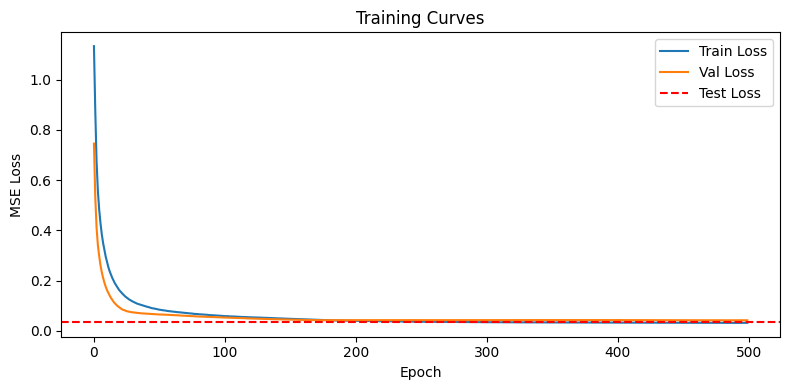

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(tr_loss, label="Train Loss")
plt.plot(vl_loss, label="Val Loss")
plt.axhline(y=test_loss, color="r", linestyle="--", label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.title("Training Curves")
plt.tight_layout()
plt.show()

---
## Compilation

`torch.compile()` JIT-compiles the model's computation graph, fusing operations and reducing Python overhead. A single line can give a significant speedup.

```python
model = torch.compile(model)
```

The first call is slower (compilation), subsequent calls are faster. Works best on Linux + CUDA.

---
## Logging

Several metrics can help understand your model. Logging them is always a good idea!

**TensorBoard** works great for PyTorch. Otherwise, cloud-based tools like Weights & Biases, neptune.ai, etc.

---
## Model Serialization

The state dictionary stores the value of all model parameters.

In [57]:
# Save
torch.save(net_hat.state_dict(), "model_weights.pt")

# Load
net_loaded = GDL_MultilayerPerceptron([5, 5, 5, 1])
net_loaded.load_state_dict(torch.load("model_weights.pt", weights_only=True))
net_loaded.eval()

# Verify
with torch.no_grad():
    sample = torch.randn(1, 5)
    assert torch.allclose(net_hat(sample), net_loaded(sample))
    print("Model loaded — predictions match!")

Model loaded — predictions match!


---
## PyTorch Ecosystem

Understanding how things work under-the-hood is worth the effort, but in practice most routine operations can be abstracted away.

Both **Lightning** and **Transformers** by HuggingFace provide APIs for training, logging, evaluating, and inference.

Also: graph neural networks, interpretability, continual learning, federated learning, quantum ML, …

---
## Your Turn! — MNIST CNN

Implement and train a **Convolutional Neural Network** to perform image classification on the MNIST dataset.

📜 Side Quests:
1. Monitor the performance with a logger
2. Play around with `dropout`, `batch_norm`, etc. (remember `train()` vs `eval()`!)
3. Try a Lightning implementation

In [58]:
import torchvision
from torchvision import transforms

torch.manual_seed(42)

# Load MNIST
transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,)),
    ]
)

mnist_train_full = torchvision.datasets.MNIST(
    "data/", train=True, download=True, transform=transform
)
mnist_test = torchvision.datasets.MNIST(
    "data/", train=False, download=True, transform=transform
)

# TODO: Split mnist_train_full into train and validation
tr_size = int(0.7 * len(mnist_train_full))
val_size = int(0.3 * len(mnist_train_full))
tr, val = torch.utils.data.random_split(mnist_train_full, (tr_size, val_size))

# TODO: Create DataLoaders
train_loader = torch.utils.data.DataLoader(tr, 32, shuffle=True)
val_loader = torch.utils.data.DataLoader(val, 32)
ts_loader = torch.utils.data.DataLoader(mnist_test, 32)

x, y = next(iter(train_loader))

print(x.shape)

# TODO: Select device
torch.device("cpu")

torch.Size([32, 1, 28, 28])


device(type='cpu')

In [59]:
import torch.nn as nn


class CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)

        self.pool = nn.MaxPool2d(2)

        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))

        x = torch.flatten(x, 1)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x


class FastCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1),  # meno filtri
            nn.ReLU(),
            nn.MaxPool2d(2),  # 28 → 14
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 14 → 7
        )

        self.fc = nn.Sequential(nn.Linear(32 * 7 * 7, 64), nn.ReLU(), nn.Linear(64, 10))

    def forward(self, x):
        x = self.conv(x)
        x = torch.flatten(x, 1)
        return self.fc(x)


class TinyCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(1, 8, 3, padding=1)
        self.fc = nn.Linear(8 * 14 * 14, 10)

    def forward(self, x):
        x = F.relu(self.conv(x))
        x = F.max_pool2d(x, 2)
        x = torch.flatten(x, 1)
        return self.fc(x)

In [60]:
from tqdm import trange

torch.set_num_threads(14)

test_loss = 0.0

cnn = FastCNN()
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(cnn.parameters(), lr=1e-2)

n_epochs = 50
tr_loss = []
vl_loss = []

for epoch in trange(n_epochs):
    # Train
    cnn.train()
    epoch_tr_loss = []
    for x, y in train_loader:
        optimizer.zero_grad()
        y_hat = cnn(x)
        loss = loss_fn(y_hat, y)
        loss.backward()
        optimizer.step()
        epoch_tr_loss.append(loss.item())

    # Validation
    cnn.eval()
    epoch_val_loss = []
    with torch.no_grad():
        for x, y in val_loader:
            y_hat = cnn(x)
            loss = loss_fn(y_hat, y)
            epoch_val_loss.append(loss.item())

    avg_tr = sum(epoch_tr_loss) / len(epoch_tr_loss)
    avg_vl = sum(epoch_val_loss) / len(epoch_val_loss)
    tr_loss.append(avg_tr)
    vl_loss.append(avg_vl)

    # Test set performance
    cnn.eval()
    test_loss_values = []
    with torch.no_grad():
        for x, y in ts_loader:
            y_hat = cnn(x)
            loss = loss_fn(y_hat, y)
            test_loss_values.append(loss.item())

    test_loss = sum(test_loss_values) / len(test_loss_values)

print(f"Test Loss: {test_loss:.4f}")

100%|██████████| 50/50 [08:53<00:00, 10.67s/it]

Test Loss: 0.0422


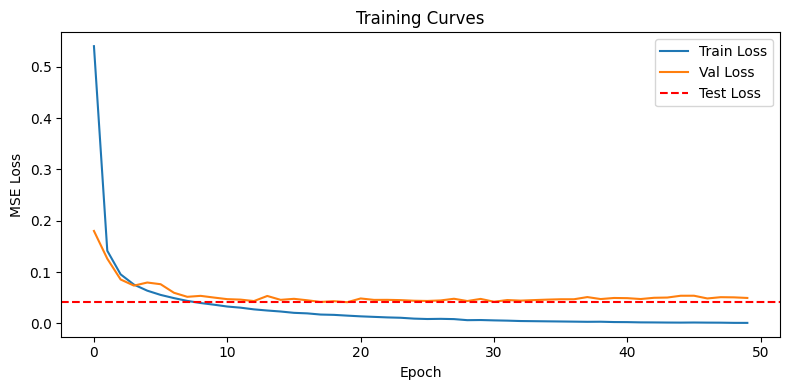

In [61]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(tr_loss, label="Train Loss")
plt.plot(vl_loss, label="Val Loss")
plt.axhline(y=test_loss, color="r", linestyle="--", label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.title("Training Curves")
plt.tight_layout()
plt.show()